# Greedy vs GA with walking speed.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
folder = 'outputs/runs/'

In [3]:
from utils.comparison_metrics import (
    build_results_table,
    extract_results,
    format_results_table,
    extract_cohens_d,
    calculate_poa,
    build_delta_table,
    plot_dispersion_all_cities,
    plot_metrics_by_human_behaviour
)
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
from utils.environment import Environment

grid = Environment('grid-like_topology')
moderate = Environment('moderate-complexity_topology')
bottleneck = Environment('bottleneck-constrained_topology')

graphs = {
    'Grid': grid.graph, 'Moderate': moderate.graph, 'Bottleneck': bottleneck.graph
}

positions = {
    'Grid': grid.pos, 'Moderate': moderate.pos, 'Bottleneck': bottleneck.pos
}


In [5]:
baseline_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
}

# Comparisons

In [6]:
experiment_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Truedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Truedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Truedelay_1compliance.pkl',
}

In [7]:
results = extract_results(experiment_files['Grid'])
print(f'Params: {results['ga']['params']}')   # {'walking': False, 'delay_start': False, ...}

Params: {'congestion': True, 'walking': False, 'delay_start': True, 'compliance': 1, 'fitness': 'max-median', 'alpha': 0.8}


### Initial Results

In [8]:
df = build_results_table(experiment_files)
formatted = format_results_table(df)
formatted.to_clipboard()
formatted

GA                                    Greedy  \
City                    Bottleneck          Grid      Moderate    Bottleneck   
Metric                                                                         
Average time          21.09 ± 0.14  10.57 ± 0.31  10.82 ± 0.35  19.50 ± 0.00   
Avg Congestion delay   8.18 ± 0.06   1.44 ± 0.18   1.55 ± 0.18   8.17 ± 0.06   
Avg Path Efficiency    1.06 ± 0.01   1.19 ± 0.03   1.12 ± 0.02   1.00 ± 0.00   
Avg path length       12.11 ± 0.16   8.31 ± 0.25   8.46 ± 0.24  10.52 ± 0.05   
Exit utilisation       0.28 ± 0.03   0.09 ± 0.04   0.09 ± 0.04   0.17 ± 0.06   
Total time            30.20 ± 0.40  15.80 ± 0.40  14.90 ± 0.30  29.00 ± 0.00   

                                                          p                   
City                          Grid      Moderate Bottleneck    Grid Moderate  
Metric                                                                        
Average time           7.47 ± 0.12  10.02 ± 0.03     0.002*  0.002*   0.002*  
Avg Congestion delay   1.66 ± 0.15   3.21 ± 0.08      0.500  0.002*   0.002*  
Avg Path Efficiency    1.00 ± 0.00   1.00 ± 0.00     0.002*  0.002*   0.002*  
Avg path length        5.00 ± 0.00   6.00 ± 0.05     0.002*  0.002*   0.002*  
Exit utilisation       0.20 ± 0.05   0.03 ± 0.02     0.002*  0.002*   0.006*  
Total time            11.40 ± 0.66  15.50 ± 0.50     0.002*  0.002*    0.062

In [9]:
extract_cohens_d(files=experiment_files)

Grid: d=4.80, p=0.002
Moderate: d=-0.90, p=0.062
Bottleneck: d=3.00, p=0.002


In [10]:
delta_df = build_delta_table(baseline_files, experiment_files, 'Baseline', 'Walking')
pivot_table = delta_df.pivot(index=['Metric', 'Algorithm'], columns='City', values='Delta')
pivot_table.to_clipboard()
pivot_table

City                            Bottleneck  Grid  Moderate
Metric               Algorithm                            
Average time         GA              -0.03  0.25     -0.01
                     GREEDY           0.00 -0.05      0.00
Avg Congestion delay GA              -0.81 -0.80     -0.81
                     GREEDY          -0.81 -0.86     -0.81
Avg Path Efficiency  GA              -0.01  0.01      0.00
                     GREEDY           0.00  0.00      0.00
Avg path length      GA              -0.03  0.24     -0.02
                     GREEDY           0.00  0.00      0.00
Exit utilisation     GA              -0.01  0.02     -0.01
                     GREEDY          -0.00  0.00      0.00
Total time           GA               0.10  0.20     -0.40
                     GREEDY           0.00  0.00      0.00

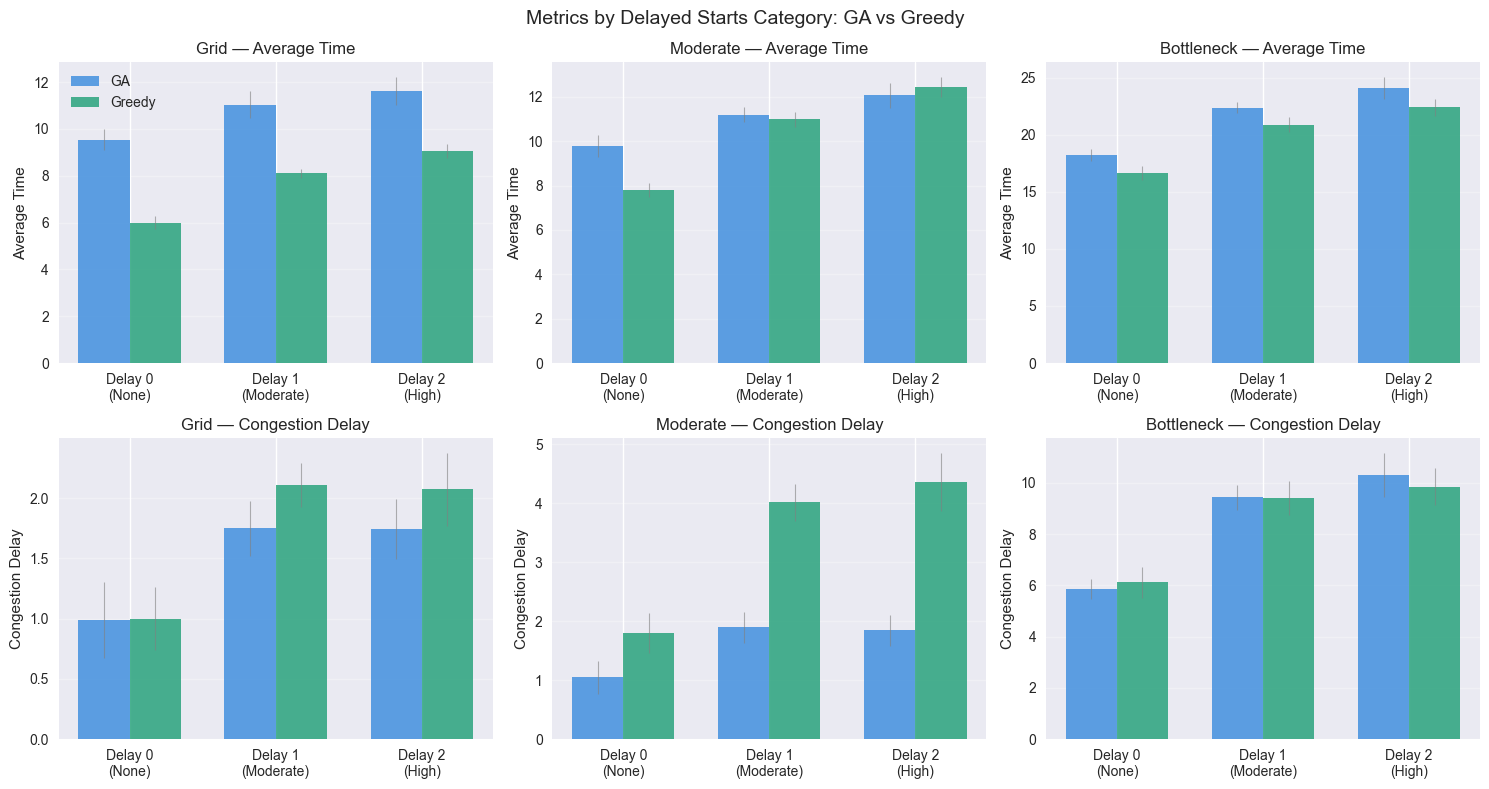

In [12]:
plot_metrics_by_human_behaviour(experiment_files, behaviour='delay_start')

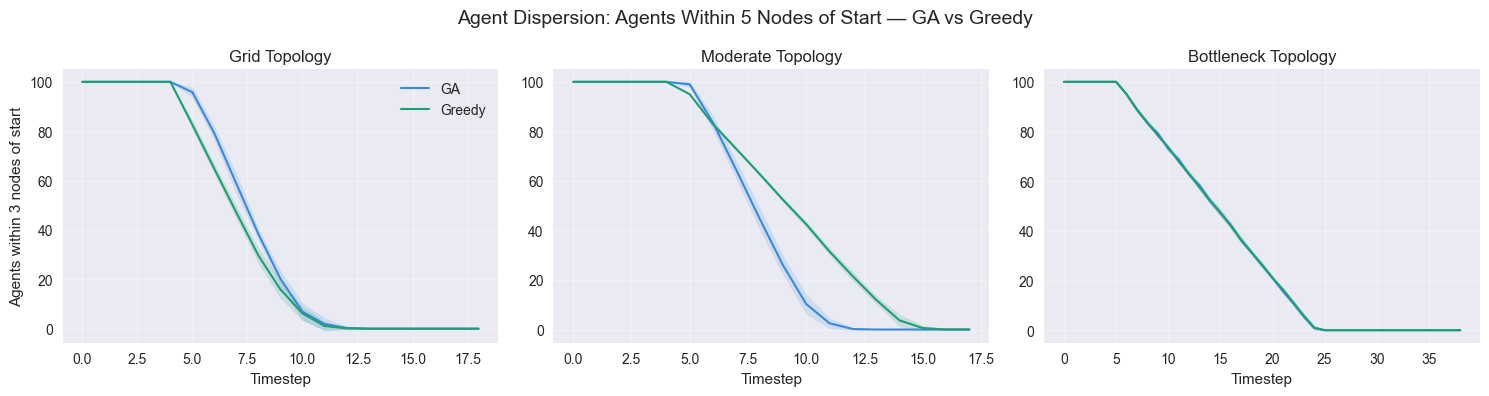

In [29]:
plot_dispersion_all_cities(experiment_files, n=5)